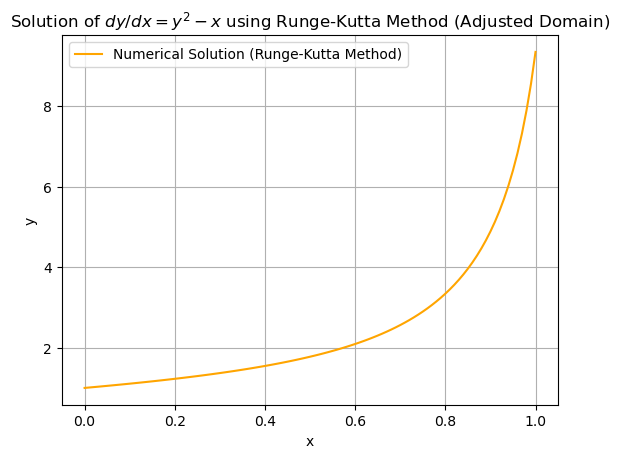

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Function representing the ODE dy/dx = y^2 - x
def dydx(x, y):
    return y**2 - x

# Fourth-order Runge-Kutta method for numerical solution of ODE
def runge_kutta_method(dydx, x0, y0, x_end, h):
    x_values = np.arange(x0, x_end + h, h)
    y_values = np.zeros(len(x_values))
    y_values[0] = y0
    
    for i in range(1, len(x_values)):
        x = x_values[i-1]
        y = y_values[i-1]
        
        k1 = h * dydx(x, y)
        k2 = h * dydx(x + h/2, y + k1/2)
        k3 = h * dydx(x + h/2, y + k2/2)
        k4 = h * dydx(x + h, y + k3)
        
        y_values[i] = y + (k1 + 2*k2 + 2*k3 + k4) / 6
    
    return x_values, y_values

# Adjust the domain to avoid large values causing overflow
x0 = 0  # Initial x
y0 = 1  # Initial y
x_end_new = 1  # Limit the domain to avoid instability
h = 0.01  # Step size

# Solve the ODE using Runge-Kutta method with a smaller domain
x_values_rk_new, y_values_rk_new = runge_kutta_method(dydx, x0, y0, x_end_new, h)

# Plot the solution with the new domain
plt.plot(x_values_rk_new, y_values_rk_new, label="Numerical Solution (Runge-Kutta Method)", color="orange")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Solution of $dy/dx = y^2 - x$ using Runge-Kutta Method (Adjusted Domain)")
plt.legend()
plt.grid(True)
plt.show()

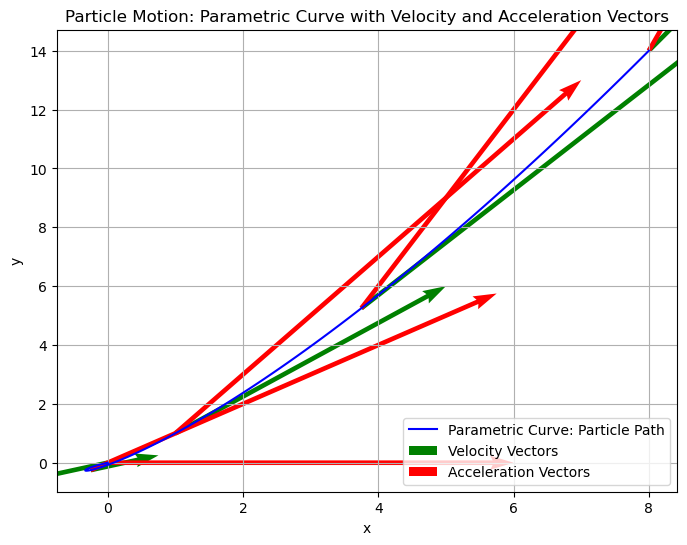

The length of the curve traced by the particle between t = 0 and t = 2 is approximately 17.10.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Define the parametric equations for x(t) and y(t)
def x(t):
    return 3 * t**2 - 2 * t

def y(t):
    return 2 * t**3 - t

# Define the velocity components
def v_x(t):
    return 6 * t - 2

def v_y(t):
    return 6 * t**2 - 1

# Define the acceleration components
def a_x(t):
    return 6

def a_y(t):
    return 12 * t

# Define the integrand for the length of the curve
def integrand(t):
    return np.sqrt(v_x(t)**2 + v_y(t)**2)

# Time range for plotting
t_vals = np.linspace(0, 2, 100)
x_vals = x(t_vals)
y_vals = y(t_vals)

# Plot the parametric curve
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label='Parametric Curve: Particle Path', color='blue')

# Calculate and plot velocity and acceleration vectors at specific points
t_points = np.array([0, 0.5, 1, 1.5, 2])
v_x_vals = v_x(t_points)
v_y_vals = v_y(t_points)
a_x_vals = np.full_like(t_points, a_x(0))  # a_x is constant, so create an array with the same length
a_y_vals = a_y(t_points)

# Plot velocity vectors
plt.quiver(x(t_points), y(t_points), v_x_vals, v_y_vals, color='green', angles='xy', scale_units='xy', scale=1, label="Velocity Vectors")

# Plot acceleration vectors
plt.quiver(x(t_points), y(t_points), a_x_vals, a_y_vals, color='red', angles='xy', scale_units='xy', scale=1, label="Acceleration Vectors")

# Labels and Title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Particle Motion: Parametric Curve with Velocity and Acceleration Vectors')
plt.grid(True)
plt.legend()
plt.show()

# Calculate the length of the curve numerically using integration
curve_length, _ = quad(integrand, 0, 2)
print(f"The length of the curve traced by the particle between t = 0 and t = 2 is approximately {curve_length:.2f}.")



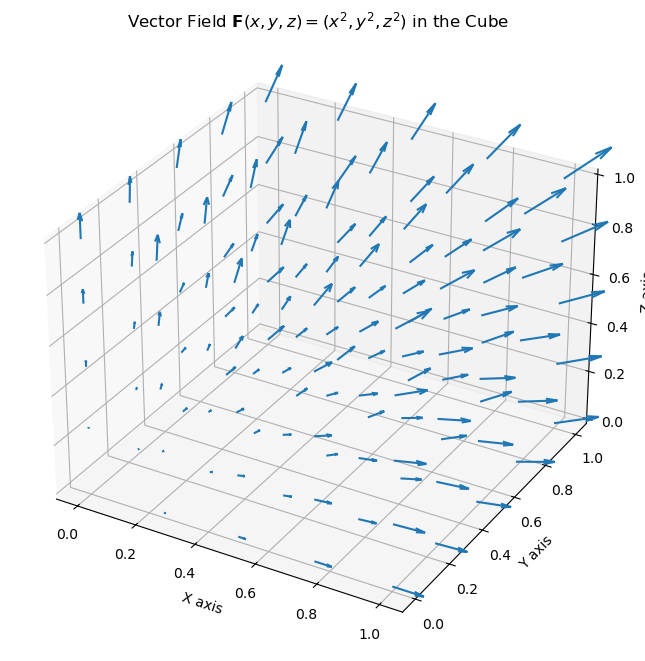

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a grid of points in the cube
x_vals, y_vals, z_vals = np.linspace(0, 1, 5), np.linspace(0, 1, 5), np.linspace(0, 1, 5)
X, Y, Z = np.meshgrid(x_vals, y_vals, z_vals)

# Define the vector field F(x, y, z) = (x^2, y^2, z^2)
U = X**2  # x component
V = Y**2  # y component
W = Z**2  # z component

# Plot the vector field using quiver
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(X, Y, Z, U, V, W, length=0.1)

# Set labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('Vector Field $\\mathbf{F}(x, y, z) = (x^2, y^2, z^2)$ in the Cube')

plt.show()


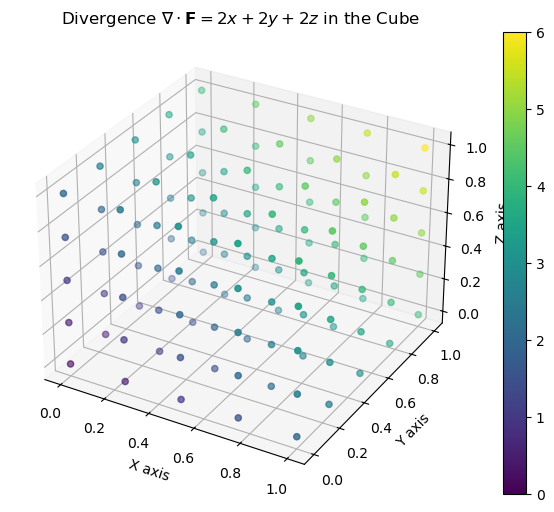

In [4]:
# Compute the divergence at each point in the cube
Divergence = 2 * X + 2 * Y + 2 * Z

# Create a 3D surface plot for the divergence
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the divergence field
divergence_plot = ax.scatter(X, Y, Z, c=Divergence, cmap='viridis', marker='o')
fig.colorbar(divergence_plot, ax=ax)

# Set labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('Divergence $\\nabla \\cdot \\mathbf{F} = 2x + 2y + 2z$ in the Cube')

plt.show()


In [5]:
# Calculate the flux through each face of the cube
# Face at x = 1
normal_x = np.array([1, 0, 0])
flux_x_face = np.dot(np.array([1, Y, Z]).T, normal_x)

# Face at y = 1
normal_y = np.array([0, 1, 0])
flux_y_face = np.dot(np.array([X, 1, Z]).T, normal_y)

# Face at z = 1
normal_z = np.array([0, 0, 1])
flux_z_face = np.dot(np.array([X, Y, 1]).T, normal_z)

# Total flux
total_flux = np.sum(flux_x_face) + np.sum(flux_y_face) + np.sum(flux_z_face)
print(f"Total surface flux: {total_flux}")


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.